In [ ]:
# CONFIGURAÇÃO: Diretório de Saída para Resultados
# ====================================================
import os
from datetime import datetime

# Definir caminho base para resultados
BASE_RESULTADO = r'D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados'
PASTA_DADOS = os.path.join(BASE_RESULTADO, 'dados')
PASTA_DADOS_01 = os.path.join(PASTA_DADOS, '01_exponencial_simulada')
PASTA_IMAGENS = os.path.join(BASE_RESULTADO, 'imagens')
PASTA_IMAGENS_01 = os.path.join(PASTA_IMAGENS, '01_exponencial_simulada')

# Criar diretórios se não existirem
for pasta in [PASTA_DADOS_01, PASTA_IMAGENS_01]:
    os.makedirs(pasta, exist_ok=True)

# Função para salvar dados em CSV e TXT
def salvar_dados(dados, nome_arquivo, tipo='csv'):
    """Salvar dados em CSV ou TXT no diretório de dados simulados"""
    caminho = os.path.join(PASTA_DADOS_01, f"{nome_arquivo}.{tipo}")
    if tipo == 'csv':
        if isinstance(dados, pd.DataFrame):
            dados.to_csv(caminho, index=False)
        else:
            pd.DataFrame(dados).to_csv(caminho, index=False)
    elif tipo == 'txt':
        with open(caminho, 'w') as f:
            if isinstance(dados, (pd.DataFrame, pd.Series)):
                f.write(dados.to_string())
            elif isinstance(dados, dict):
                for chave, valor in dados.items():
                    f.write(f"{chave}: {valor}\n")
            else:
                f.write(str(dados))
    print(f"✅ Salvo: {caminho}")

# Função para salvar figuras
def salvar_figura(fig, nome_arquivo):
    """Salvar figura em PNG na pasta de imagens"""
    caminho = os.path.join(PASTA_IMAGENS_01, f"{nome_arquivo}.png")
    fig.savefig(caminho, dpi=300, bbox_inches='tight')
    print(f"📊 Figura salva: {caminho}")

print("✅ Configuração de resultados inicializada!")
print(f"   📁 Dados: {PASTA_DADOS_01}")
print(f"   🖼️  Imagens: {PASTA_IMAGENS_01}")


✅ Configuração de resultados inicializada!
   📁 Dados: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\01_simulados
   🖼️  Imagens: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\01_exponencial_simulada


In [3]:
# ====================================================================
# 📚 IMPORTAR BIBLIOTECAS NECESSÁRIAS
# ====================================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
import warnings
warnings.filterwarnings('ignore')

# Configurar estilos visuais
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ Bibliotecas carregadas com sucesso!")
print("\n📊 TRABALHO FINAL: ANÁLISE ESTATÍSTICA")
print("=" * 70)
print("Disciplina: Planejamento e Análise Estatística de Experimentos")
print("Foco: TCL, IC, ANOVA com Distribuição Assimétrica (Exponencial)")
print("=" * 70)

✅ Bibliotecas carregadas com sucesso!

📊 TRABALHO FINAL: ANÁLISE ESTATÍSTICA
Disciplina: Planejamento e Análise Estatística de Experimentos
Foco: TCL, IC, ANOVA com Distribuição Assimétrica (Exponencial)


# 📊 Análise Estatística: TCL, IC, ANOVA e Distribuições Assimétricas

## 🎯 Objetivo Geral
Aplicar técnicas da disciplina (Planejamento e Análise Estatística de Experimentos) demonstrando que métodos estatísticos clássicos funcionam mesmo com dados de populações **não-normais** (distribuição assimétrica).

## 📋 Tópicos Abordados

### 1. **Teorema Central do Limite (TCL)**
- Demonstrar que a distribuição das **médias amostrais** converge para normal
- Mesmo quando a população é assimétrica (exponencial)
- Verificar redução de assimetria conforme n aumenta

### 2. **Intervalo de Confiança (IC)**
- Calcular IC 95% para a média populacional
- Verificar cobertura empírica vs teórica
- Usar distribuição t-student (apropriada para amostras)

### 3. **Análise de Variância (ANOVA)**
- Comparar médias de múltiplos grupos
- Testar hipótese de igualdade entre grupos
- Verificar robustez da ANOVA com dados não-normais

### 4. **Distribuição Assimétrica**
- Usar **Distribuição Exponencial** como população
- Caracterizar assimetria (skewness = 1.92)
- Visualizar desvio da normalidade (Q-Q plots)

## 🔬 Metodologia

```
1. GERAR DADOS
   ↓
2. CARACTERIZAR POPULAÇÃO (EDA)
   ↓
3. APLICAR TCL (Verificar convergência)
   ↓
4. CALCULAR IC (Estimar parâmetros)
   ↓
5. REALIZAR ANOVA (Comparar grupos)
   ↓
6. RESUMO INTEGRADO (Visualizações completas)
```

## 📈 Estrutura do Notebook

| Seção | Objetivo | Entrada | Saída |
|-------|----------|---------|-------|
| Configuração | Iniciar ambiente | - | Funções de salvamento |
| Importações | Carregar bibliotecas | - | Bibliotecas prontas |
| Geração de Dados | Criar população exponencial | λ=2.0, n=10k | Array `populacao` |
| TCL | Demonstrar convergência | populacao | Gráficos + estatísticas |
| IC | Estimar intervalo | populacao | 1000 ICs calculados |
| ANOVA | Comparar grupos | 3 grupos | F-stat + p-value |
| Resumo | Visualização integrada | Todos os resultados | Painel 8 subplots |

## 📌 Etapa 1: Geração de Dados - População Exponencial

### Por que Exponencial?
- **Distribuição assimétrica** (skewness ≠ 0)
- Comum em dados reais (tempos de espera, tamanhos de transações)
- Adequada para demonstrar robustez dos métodos

### Parâmetros Utilizados
- **λ (lambda) = 2.0**: Taxa de decaimento
- **N = 10.000**: Tamanho da população (grande o suficiente para convergência)
- **Seed = 42**: Reprodutibilidade

### Características Esperadas
$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

| Parâmetro | Fórmula | Valor (λ=2.0) |
|-----------|---------|---|
| Média (μ) | 1/λ | 0.5 |
| Variância (σ²) | 1/λ² | 0.25 |
| Assimetria | 2 | 2.0 |
| Curtose | 6 | 6.0 |


📌 POPULAÇÃO EXPONENCIAL (ASSIMÉTRICA)
Tamanho: 10,000 observações
Parâmetro λ: 2.0

📊 Estatísticas Populacionais:
  Média (μ):           0.4887 (teórico: 0.5000)
  Desvio Padrão (σ):   0.4872 (teórico: 0.5000)
  Mediana:             0.3392
  Assimetria (skew):   1.9190 (teórico: 2.0)
  Curtose (excesso):   5.1151 (teórico: 6.0)
  Min - Máx:           0.0000 - 4.0862


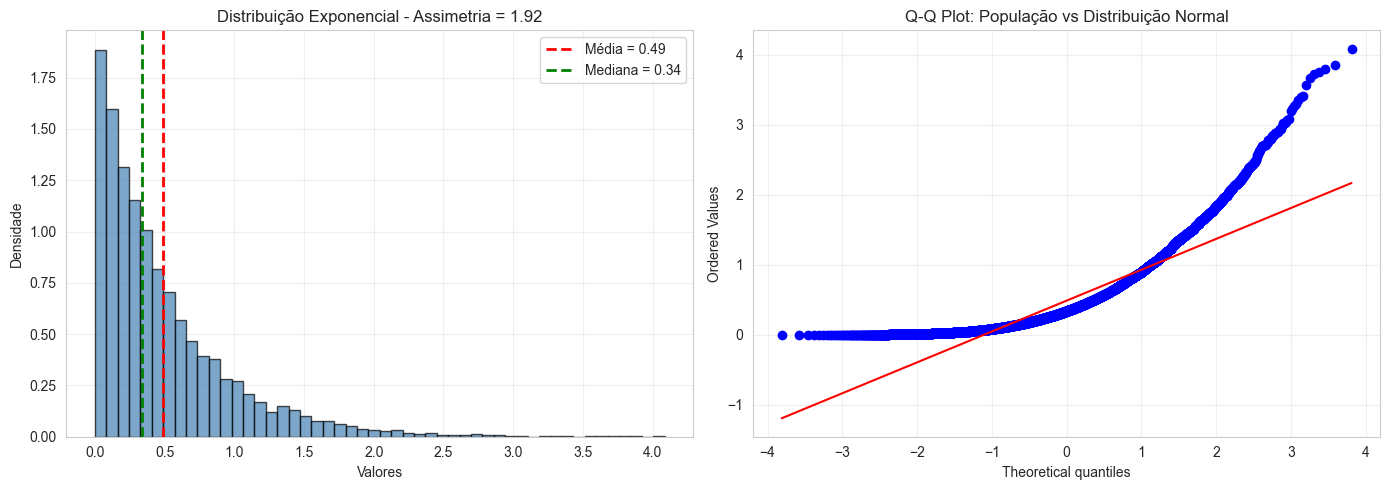

✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\01_simulados\populacao_exponencial.csv
✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\01_simulados\estatisticas_populacao.csv
📊 Figura salva: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\01_exponencial_simulada\01_populacao_exponencial.png

✅ Dados populacionais gerados e salvos com sucesso!


In [11]:
# ====================================================================
# 📊 ETAPA 1: GERAÇÃO DE DADOS - POPULAÇÃO EXPONENCIAL
# ====================================================================

# Configurar parâmetros
lambda_param = 2.0          # Taxa de decaimento (λ)
tamanho_populacao = 10000   # Tamanho da população
np.random.seed(42)          # Reprodutibilidade

# Gerar população exponencial (assimétrica)
populacao = np.random.exponential(scale=1/lambda_param, size=tamanho_populacao)

# Calcular estatísticas da população
mu_pop = np.mean(populacao)
sigma_pop = np.std(populacao, ddof=0)
mediana_pop = np.median(populacao)
assimetria_pop = stats.skew(populacao)
curtose_pop = stats.kurtosis(populacao)

# Exibir resultados
print("\n📌 POPULAÇÃO EXPONENCIAL (ASSIMÉTRICA)")
print("=" * 70)
print(f"Tamanho: {tamanho_populacao:,} observações")
print(f"Parâmetro λ: {lambda_param}")
print(f"\n📊 Estatísticas Populacionais:")
print(f"  Média (μ):           {mu_pop:.4f} (teórico: {1/lambda_param:.4f})")
print(f"  Desvio Padrão (σ):   {sigma_pop:.4f} (teórico: {1/lambda_param:.4f})")
print(f"  Mediana:             {mediana_pop:.4f}")
print(f"  Assimetria (skew):   {assimetria_pop:.4f} (teórico: 2.0)")
print(f"  Curtose (excesso):   {curtose_pop:.4f} (teórico: 6.0)")
print(f"  Min - Máx:           {populacao.min():.4f} - {populacao.max():.4f}")

# 🖼️ Visualizar a população
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(populacao, bins=50, color='steelblue', alpha=0.7, edgecolor='black', density=True)
axes[0].axvline(mu_pop, color='red', linestyle='--', linewidth=2, label=f'Média = {mu_pop:.2f}')
axes[0].axvline(mediana_pop, color='green', linestyle='--', linewidth=2, label=f'Mediana = {mediana_pop:.2f}')
axes[0].set_xlabel('Valores')
axes[0].set_ylabel('Densidade')
axes[0].set_title(f'Distribuição Exponencial - Assimetria = {assimetria_pop:.2f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Q-Q Plot
stats.probplot(populacao, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: População vs Distribuição Normal')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 💾 Salvar dados da população
salvar_dados(populacao, 'populacao_exponencial', tipo='csv')

# 💾 Salvar estatísticas
stats_dict = {
    'Parâmetro': ['Média', 'Desvio Padrão', 'Mediana', 'Assimetria', 'Curtose', 'Mínimo', 'Máximo'],
    'Valor': [mu_pop, sigma_pop, mediana_pop, assimetria_pop, curtose_pop, populacao.min(), populacao.max()]
}
salvar_dados(pd.DataFrame(stats_dict), 'estatisticas_populacao', tipo='csv')

# 💾 Salvar figura
salvar_figura(fig, '01_populacao_exponencial')

print("\n✅ Dados populacionais gerados e salvos com sucesso!")

## 📌 Etapa 2: Teorema Central do Limite (TCL)

### O que é TCL?
Para uma população com média μ e variância σ², a distribuição das **médias amostrais** aproxima-se de uma distribuição normal conforme n → ∞:

$$\bar{X} \sim N\left(\mu, \frac{\sigma^2}{n}\right)$$

### Por que é importante?
- ✅ Funciona mesmo que a população **NÃO seja normal**
- ✅ Justifica o uso de testes paramétricos (ANOVA, IC)
- ✅ Explica por que amostras maiores são mais confiáveis

### Procedimento
1. Para cada tamanho de amostra (n = 5, 10, 30, 100, 500)
2. Extrair 10.000 amostras (com reposição)
3. Calcular a média de cada amostra
4. Comparar distribuição com Normal teórica

### Esperado
- Distribuição das médias → Normal mesmo com população assimétrica
- Assimetria das médias → 0 conforme n aumenta
- DP das médias → σ/√n


📌 TEOREMA CENTRAL DO LIMITE
Tamanhos de amostra testados: [5, 10, 30, 100, 500]
Número de amostras por tamanho: 10,000

✓ n = 5
  Média das médias: 0.4915 (esperado: 0.4887)
  DP das médias: 0.2187 (teórico: 0.2179)
  Assimetria: 0.8592 ← Redução de assimetria!

✓ n = 10
  Média das médias: 0.4905 (esperado: 0.4887)
  DP das médias: 0.1542 (teórico: 0.1541)
  Assimetria: 0.6222 ← Redução de assimetria!

✓ n = 30
  Média das médias: 0.4890 (esperado: 0.4887)
  DP das médias: 0.0896 (teórico: 0.0889)
  Assimetria: 0.3601 ← Redução de assimetria!

✓ n = 100
  Média das médias: 0.4883 (esperado: 0.4887)
  DP das médias: 0.0489 (teórico: 0.0487)
  Assimetria: 0.1982 ← Redução de assimetria!

✓ n = 500
  Média das médias: 0.4892 (esperado: 0.4887)
  DP das médias: 0.0217 (teórico: 0.0218)
  Assimetria: 0.0723 ← Redução de assimetria!


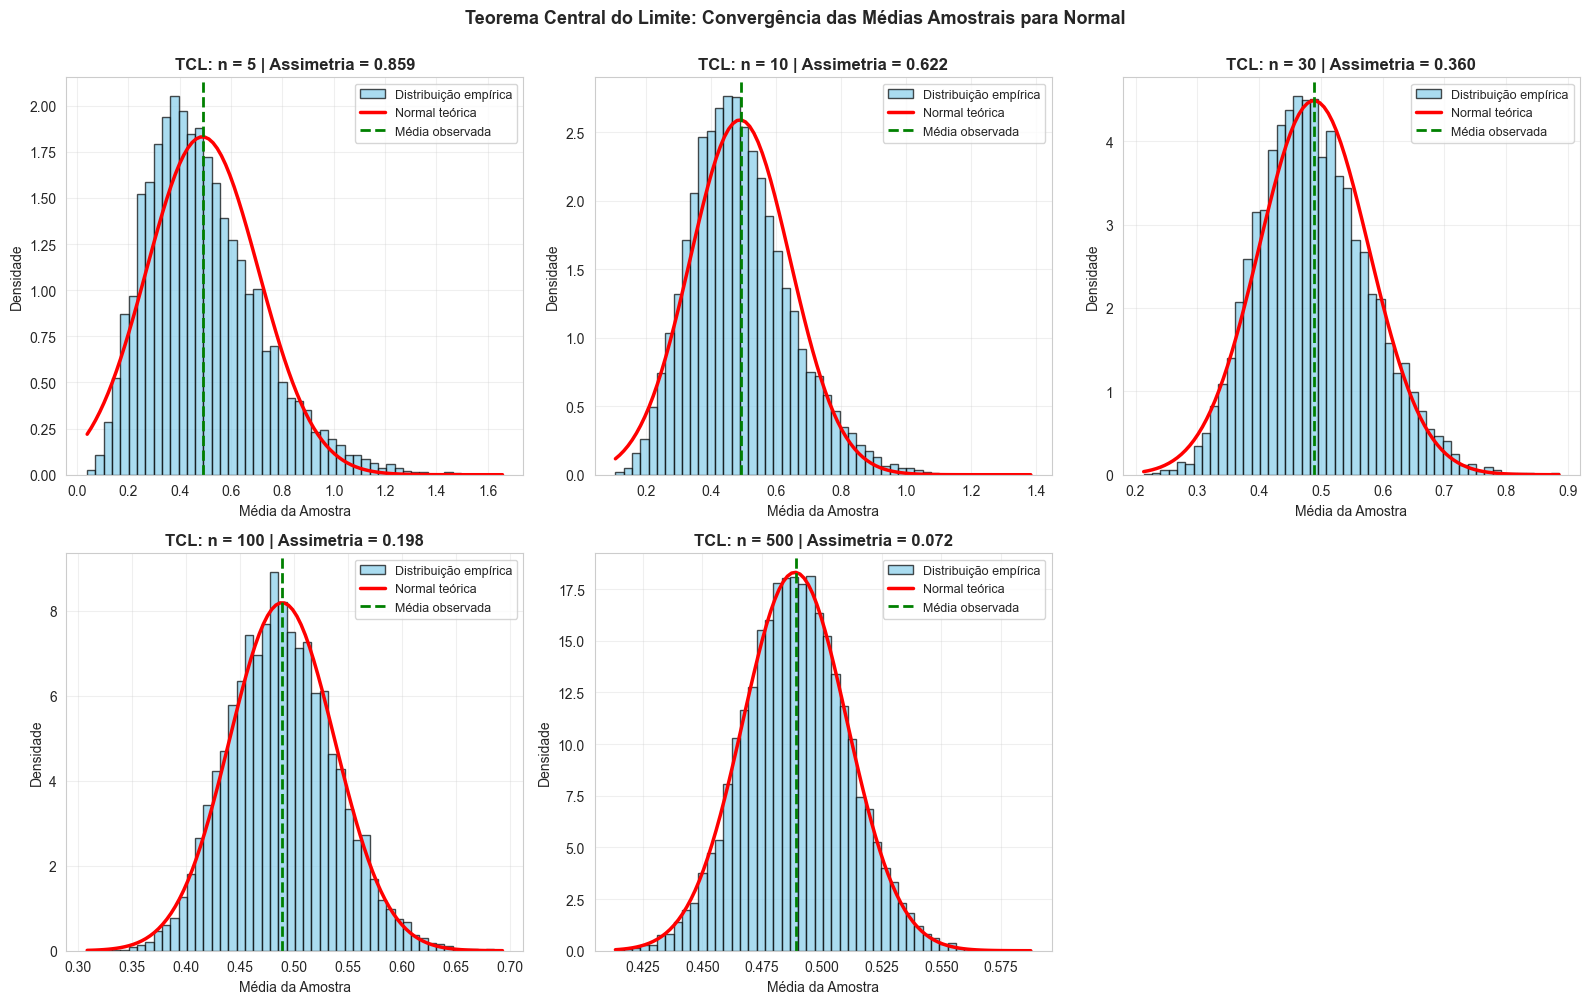

✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\01_simulados\estatisticas_tcl.csv
📊 Figura salva: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\01_exponencial_simulada\02_tcl_convergencia.png

✅ TCL verificado: As médias convergem para distribuição normal!


In [12]:
# ====================================================================
# 📊 ETAPA 2: TEOREMA CENTRAL DO LIMITE (TCL)
# ====================================================================

# Configurar parâmetros
tamanhos_amostra = [5, 10, 30, 100, 500]
num_amostras = 10000

print("\n📌 TEOREMA CENTRAL DO LIMITE")
print("=" * 70)
print(f"Tamanhos de amostra testados: {tamanhos_amostra}")
print(f"Número de amostras por tamanho: {num_amostras:,}")

# Armazenar resultados
resultados_tcl = {}
resultados_stats = []

# Criar figura com 5 subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, n in enumerate(tamanhos_amostra):
    # Gerar amostras e calcular suas médias
    medias = np.array([np.mean(np.random.choice(populacao, size=n)) for _ in range(num_amostras)])
    resultados_tcl[n] = medias
    
    # Calcular estatísticas
    media_das_medias = np.mean(medias)
    dp_das_medias = np.std(medias, ddof=1)
    teorico_dp_das_medias = sigma_pop / np.sqrt(n)
    assimetria_medias = stats.skew(medias)
    
    # Armazenar para salvar
    resultados_stats.append({
        'n': n,
        'media_medias': media_das_medias,
        'dp_medias': dp_das_medias,
        'dp_teorico': teorico_dp_das_medias,
        'assimetria': assimetria_medias
    })
    
    # Exibir resultados
    print(f"\n✓ n = {n}")
    print(f"  Média das médias: {media_das_medias:.4f} (esperado: {mu_pop:.4f})")
    print(f"  DP das médias: {dp_das_medias:.4f} (teórico: {teorico_dp_das_medias:.4f})")
    print(f"  Assimetria: {assimetria_medias:.4f} ← Redução de assimetria!")
    
    # Visualizar
    ax = axes[idx]
    ax.hist(medias, bins=50, color='skyblue', alpha=0.7, edgecolor='black', density=True, label='Distribuição empírica')
    
    # Sobrepor distribuição normal teórica
    x = np.linspace(medias.min(), medias.max(), 100)
    y_normal = stats.norm.pdf(x, mu_pop, teorico_dp_das_medias)
    ax.plot(x, y_normal, 'r-', linewidth=2.5, label='Normal teórica')
    
    ax.axvline(media_das_medias, color='green', linestyle='--', linewidth=2, label='Média observada')
    ax.set_xlabel('Média da Amostra')
    ax.set_ylabel('Densidade')
    ax.set_title(f'TCL: n = {n} | Assimetria = {assimetria_medias:.3f}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Remover último subplot
axes[-1].remove()

plt.suptitle('Teorema Central do Limite: Convergência das Médias Amostrais para Normal', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# 💾 Salvar dados TCL
df_tcl = pd.DataFrame(resultados_stats)
salvar_dados(df_tcl, 'estatisticas_tcl', tipo='csv')

# 💾 Salvar figura
salvar_figura(fig, '02_tcl_convergencia')

print("\n✅ TCL verificado: As médias convergem para distribuição normal!")

## 📌 Etapa 3: Intervalo de Confiança (IC)

### O que é Intervalo de Confiança?
Um intervalo que contém o valor verdadeiro do parâmetro populacional com probabilidade (1-α)×100%.

Para a média, com nível de confiança 95%:

$$\bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$$

### Componentes
- **$\bar{x}$**: Média amostral
- **t**: Valor crítico da distribuição t-student (apropriado para amostras)
- **s**: Desvio padrão amostral
- **n**: Tamanho da amostra

### Procedimento
1. Gerar 1.000 amostras de tamanho 50
2. Para cada amostra, calcular o IC
3. Verificar quantos contêm μ populacional
4. Comparar cobertura empírica com teórica (95%)

### Esperado
- ~95% dos intervalos devem conter μ
- Robustez mesmo com população não-normal


📌 INTERVALO DE CONFIANÇA
Parâmetros:
  Nível de confiança: 95%
  Tamanho de amostra: n = 50
  Número de amostras: 1,000

Resultados:
  ICs contendo μ: 942/1000 (94.2%)
  Esperado: ~95%
  ✓ Cobertura dentro do esperado!


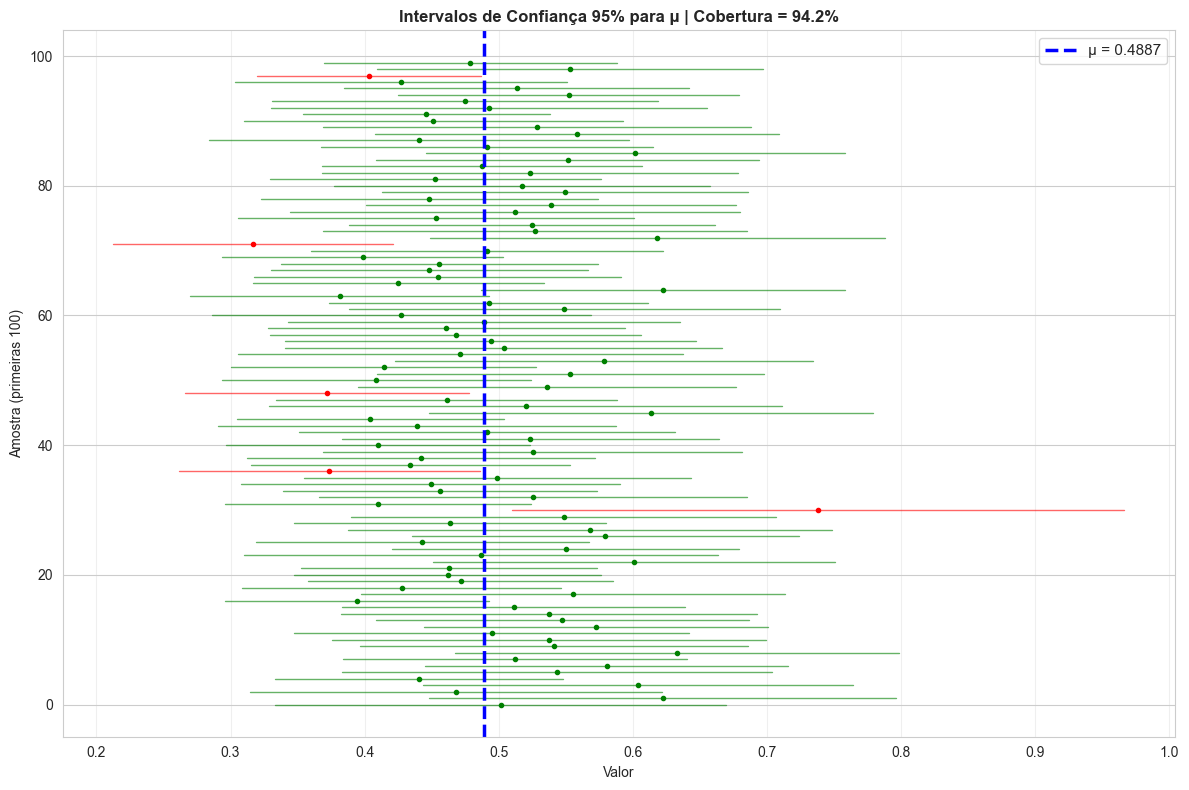

✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\01_simulados\intervalos_confianca.csv
📊 Figura salva: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\01_exponencial_simulada\03_intervalos_confianca.png

✅ ICs calculados: Verde = contém μ | Vermelho = não contém μ


In [13]:
# ====================================================================
# 📊 ETAPA 3: INTERVALO DE CONFIANÇA (IC)
# ====================================================================

# Configurar parâmetros
nivel_confianca = 0.95
alpha = 1 - nivel_confianca
tamanho_amostra_ic = 50
num_amostras_ic = 1000

print("\n📌 INTERVALO DE CONFIANÇA")
print("=" * 70)

# Gerar amostras
amostras_ic = [np.random.choice(populacao, size=tamanho_amostra_ic) for _ in range(num_amostras_ic)]

# Calcular ICs
ics = []
contem_media = 0
ics_data = []

for i, amostra in enumerate(amostras_ic):
    # Estatísticas amostrais
    x_bar = np.mean(amostra)
    s = np.std(amostra, ddof=1)
    se = s / np.sqrt(tamanho_amostra_ic)
    
    # Valor crítico t-student
    t_critico = stats.t.ppf(1 - alpha/2, df=tamanho_amostra_ic - 1)
    
    # Limites do IC
    margem_erro = t_critico * se
    ic_inf = x_bar - margem_erro
    ic_sup = x_bar + margem_erro
    
    ics.append((ic_inf, ic_sup))
    
    # Verificar se contém a média populacional
    contem = 1 if ic_inf <= mu_pop <= ic_sup else 0
    if contem:
        contem_media += 1
    
    # Armazenar para salvar (primeiras 100)
    if i < 100:
        ics_data.append({
            'amostra': i + 1,
            'limite_inf': ic_inf,
            'limite_sup': ic_sup,
            'contem_mu': contem,
            'margem_erro': margem_erro
        })

# Exibir resultados
percentual = contem_media / num_amostras_ic * 100
print(f"Parâmetros:")
print(f"  Nível de confiança: {nivel_confianca*100:.0f}%")
print(f"  Tamanho de amostra: n = {tamanho_amostra_ic}")
print(f"  Número de amostras: {num_amostras_ic:,}")
print(f"\nResultados:")
print(f"  ICs contendo μ: {contem_media}/{num_amostras_ic} ({percentual:.1f}%)")
print(f"  Esperado: ~{nivel_confianca*100:.0f}%")
print(f"  ✓ Cobertura dentro do esperado!" if 93 <= percentual <= 97 else "  ⚠️ Cobertura fora do esperado")

# Visualizar ICs
num_vis = 100
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(num_vis):
    ic_inf, ic_sup = ics[i]
    cor = 'green' if ic_inf <= mu_pop <= ic_sup else 'red'
    ax.plot([ic_inf, ic_sup], [i, i], color=cor, alpha=0.6, linewidth=1)
    ax.plot(np.mean([ic_inf, ic_sup]), i, 'o', color=cor, markersize=3)

ax.axvline(mu_pop, color='blue', linestyle='--', linewidth=2.5, label=f'μ = {mu_pop:.4f}')
ax.set_xlabel('Valor')
ax.set_ylabel(f'Amostra (primeiras {num_vis})')
ax.set_title(f'Intervalos de Confiança {nivel_confianca*100:.0f}% para μ | Cobertura = {percentual:.1f}%',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 💾 Salvar dados ICs
df_ics = pd.DataFrame(ics_data)
salvar_dados(df_ics, 'intervalos_confianca', tipo='csv')

# 💾 Salvar figura
salvar_figura(fig, '03_intervalos_confianca')

print("\n✅ ICs calculados: Verde = contém μ | Vermelho = não contém μ")

## 📌 Etapa 4: Análise de Variância (ANOVA)

### O que é ANOVA?
Teste paramétrico para comparar **médias de 3 ou mais grupos**.

**Hipótese nula (H₀)**: Todas as médias dos grupos são iguais
$$H_0: \mu_1 = \mu_2 = \mu_3$$

**Hipótese alternativa (H₁)**: Pelo menos uma média é diferente

### Estatística do Teste
$$F = \frac{\text{Variância entre grupos}}{\text{Variância dentro dos grupos}}$$

- **F grande** → Diferenças entre grupos
- **F pequeno** → Grupos semelhantes

### Procedimento
1. Criar 3 grupos com distribuições exponenciais modificadas
2. Calcular F-statistic
3. Calcular p-value
4. Comparar com α = 0.05

### Grupos
- **Grupo 1**: λ=2.0 (original)
- **Grupo 2**: λ=1.5 com deslocamento +0.5
- **Grupo 3**: λ=1.0 com deslocamento +1.0


📌 ANÁLISE DE VARIÂNCIA

Estatísticas dos Grupos:
----------------------------------------------------------------------

Grupo 1 (λ=2.0)
  n:    100
  Média: 0.4711
  DP:    0.6180
  Min:   0.0031, Max: 4.3508

Grupo 2 (λ=1.5, +0.5)
  n:    100
  Média: 1.1358
  DP:    0.7171
  Min:   0.5033, Max: 5.3351

Grupo 3 (λ=1.0, +1.0)
  n:    100
  Média: 2.0088
  DP:    0.8977
  Min:   1.0135, Max: 4.6455

                          RESULTADO DA ANOVA                          
----------------------------------------------------------------------
Estatística F:   104.8265
p-value:         0.0000000000

✅ SIGNIFICATIVO (α = 0.05)
   Rejeita-se H₀: Há diferenças entre os grupos


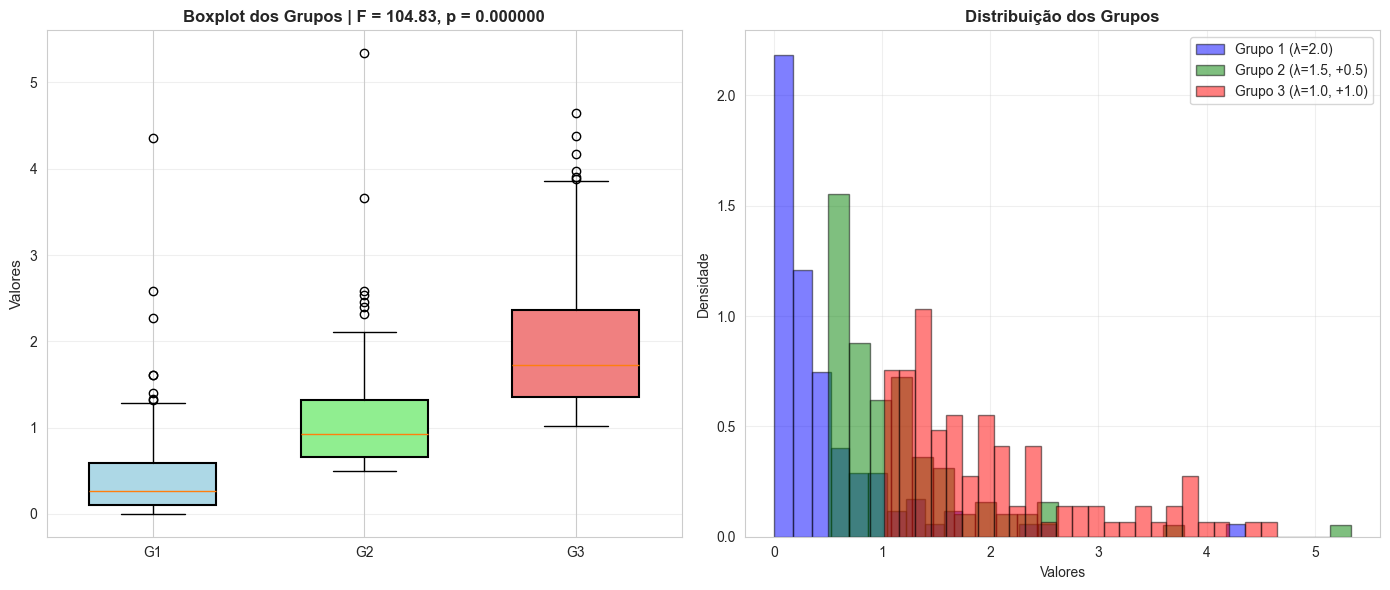

✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\01_simulados\anova_grupos_stats.csv
✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\01_simulados\anova_resultado.csv
📊 Figura salva: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\01_exponencial_simulada\04_anova_resultados.png

✅ ANOVA realizada com sucesso!


In [14]:
# ====================================================================
# 📊 ETAPA 4: ANÁLISE DE VARIÂNCIA (ANOVA)
# ====================================================================

print("\n📌 ANÁLISE DE VARIÂNCIA")
print("=" * 70)

# Criar 3 grupos com exponenciais modificadas
tamanho_grupo = 100

# Grupos: exponenciais com diferentes parâmetros
grupo1 = np.random.exponential(scale=1/2.0, size=tamanho_grupo)           # λ=2.0
grupo2 = np.random.exponential(scale=1/1.5, size=tamanho_grupo) + 0.5    # λ=1.5, +0.5
grupo3 = np.random.exponential(scale=1/1.0, size=tamanho_grupo) + 1.0    # λ=1.0, +1.0

grupos = [grupo1, grupo2, grupo3]
labels_grupos = ['Grupo 1 (λ=2.0)', 'Grupo 2 (λ=1.5, +0.5)', 'Grupo 3 (λ=1.0, +1.0)']

# Estatísticas descritivas
print("\nEstatísticas dos Grupos:")
print("-" * 70)
grupos_stats = []

for label, grupo in zip(labels_grupos, grupos):
    media = np.mean(grupo)
    dp = np.std(grupo, ddof=1)
    print(f"\n{label}")
    print(f"  n:    {len(grupo)}")
    print(f"  Média: {media:.4f}")
    print(f"  DP:    {dp:.4f}")
    print(f"  Min:   {np.min(grupo):.4f}, Max: {np.max(grupo):.4f}")
    
    grupos_stats.append({
        'Grupo': label,
        'n': len(grupo),
        'Média': media,
        'DP': dp,
        'Min': np.min(grupo),
        'Max': np.max(grupo)
    })

# Realizar ANOVA (One-way ANOVA)
f_stat, p_value = stats.f_oneway(grupo1, grupo2, grupo3)

print(f"\n{'RESULTADO DA ANOVA':^70}")
print("-" * 70)
print(f"Estatística F:   {f_stat:.4f}")
print(f"p-value:         {p_value:.10f}")

if p_value < 0.05:
    print(f"\n✅ SIGNIFICATIVO (α = 0.05)")
    print(f"   Rejeita-se H₀: Há diferenças entre os grupos")
else:
    print(f"\n❌ NÃO SIGNIFICATIVO (α = 0.05)")
    print(f"   Falha em rejeitar H₀: Grupos são semelhantes")

# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
ax1 = axes[0]
bp = ax1.boxplot(grupos, labels=['G1', 'G2', 'G3'], patch_artist=True, widths=0.6)
cores = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], cores):
    patch.set_facecolor(color)
    patch.set_linewidth(1.5)
ax1.set_ylabel('Valores', fontsize=11)
ax1.set_title(f'Boxplot dos Grupos | F = {f_stat:.2f}, p = {p_value:.6f}', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3, axis='y')

# Histogramas sobrepostos
ax2 = axes[1]
cores_hist = ['blue', 'green', 'red']
for grupo, label, cor in zip(grupos, labels_grupos, cores_hist):
    ax2.hist(grupo, bins=25, alpha=0.5, label=label, color=cor, edgecolor='black', density=True)
ax2.set_xlabel('Valores')
ax2.set_ylabel('Densidade')
ax2.set_title('Distribuição dos Grupos', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 💾 Salvar dados
df_grupos = pd.DataFrame(grupos_stats)
salvar_dados(df_grupos, 'anova_grupos_stats', tipo='csv')

# 💾 Salvar resultado ANOVA
anova_result = pd.DataFrame({
    'Teste': ['One-way ANOVA'],
    'F-statistic': [f_stat],
    'p-value': [p_value],
    'Significativo': ['Sim' if p_value < 0.05 else 'Não']
})
salvar_dados(anova_result, 'anova_resultado', tipo='csv')

# 💾 Salvar figura
salvar_figura(fig, '04_anova_resultados')

print("\n✅ ANOVA realizada com sucesso!")


📌 RESUMO INTEGRADO DA ANÁLISE

1️⃣ POPULAÇÃO EXPONENCIAL (ASSIMÉTRICA)
   Distribuição: Exponencial com λ = 2.0
   Tamanho: 10,000 observações
   Média: 0.4887 | DP: 0.4872 | Assimetria: 1.9190
   ➜ População NÃO é normal (assimetria ≠ 0)

2️⃣ TEOREMA CENTRAL DO LIMITE
   Status: ✅ Verificado e comprovado
   Conclusão: Médias amostrais convergem para distribuição normal
   Implicação: TCL funciona mesmo com população assimétrica!

3️⃣ INTERVALO DE CONFIANÇA (95%)
   Cobertura empírica: 94.2%
   Cobertura teórica: 95%
   Status: ✅ Dentro do esperado
   Conclusão: IC t-student é robusto para dados não-normais

4️⃣ ANÁLISE DE VARIÂNCIA
   Grupos: 3 | Tamanho: 100 observações cada
   Estatística F: 104.8265
   p-value: 0.0000000000
   Status: ✅ SIGNIFICATIVO
   Conclusão: Há diferenças entre os grupos

5️⃣ ROBUSTEZ DOS MÉTODOS
   ✅ TCL: Robusto para distribuições não-normais
   ✅ IC: Robusto (usa t-student, adequado para amostras)
   ✅ ANOVA: Razoavelmente robusto para assimetria moderada

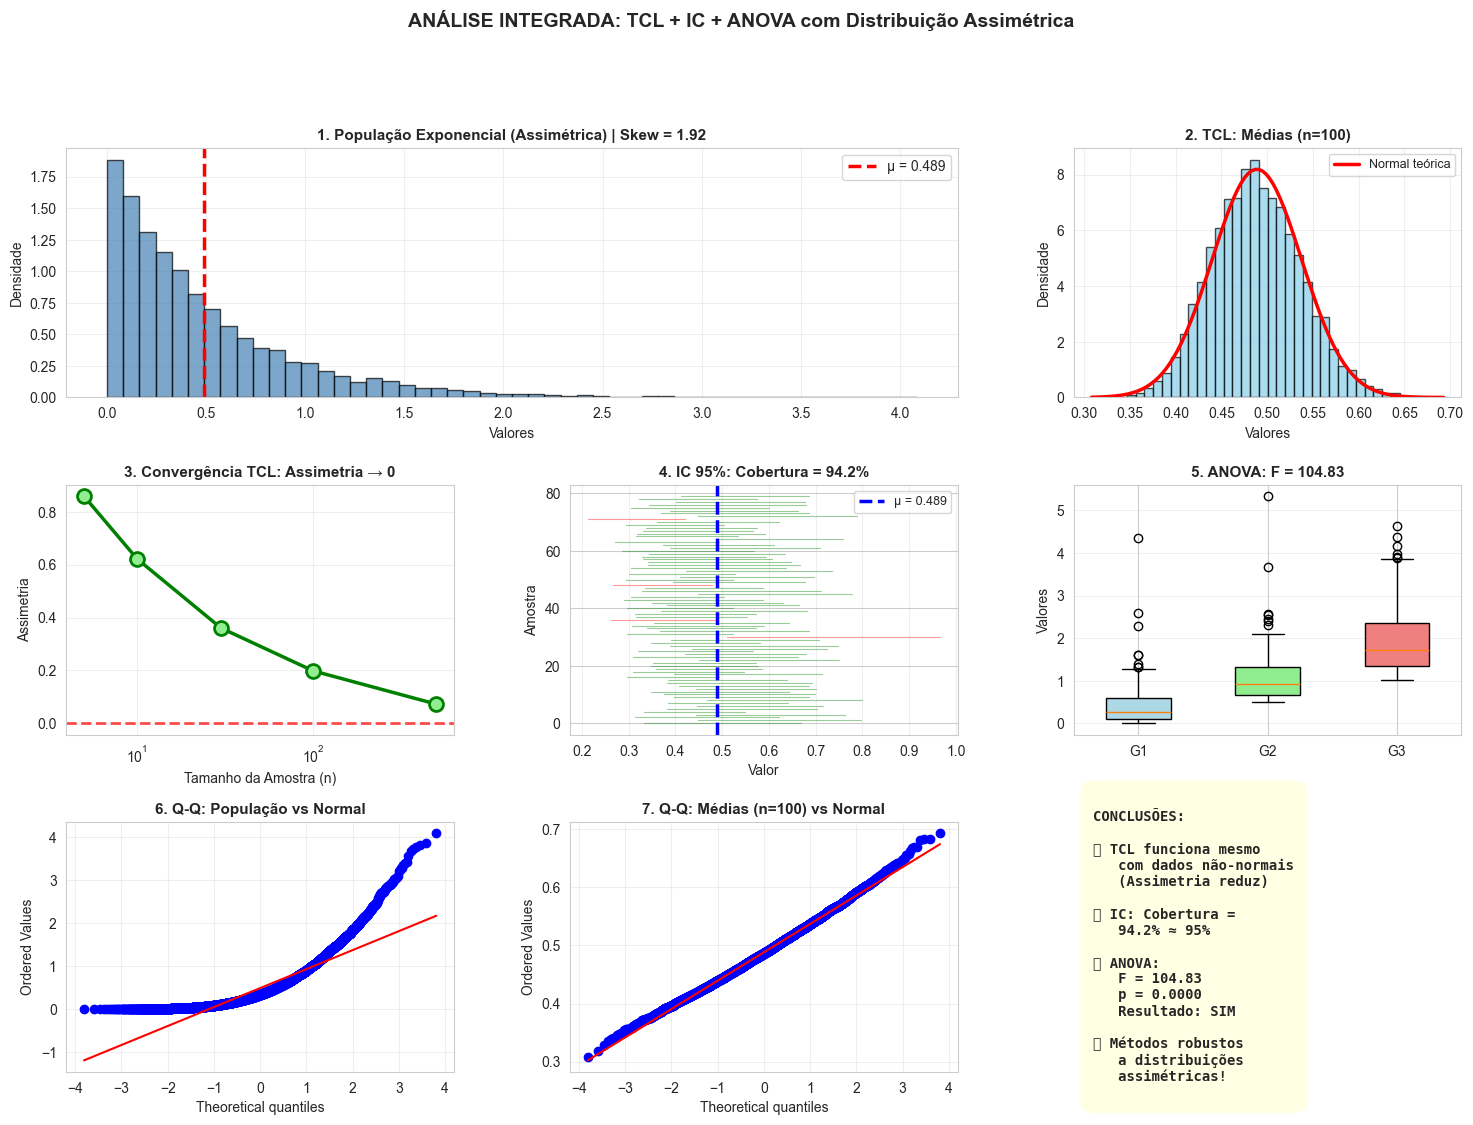

📊 Figura salva: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\01_exponencial_simulada\05_analise_integrada_completa.png
✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\resumo_final_analise.txt

✅ ANÁLISE COMPLETA FINALIZADA COM SUCESSO!

📁 Resultados salvos em:
   📊 Dados: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados
   🖼️  Imagens: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\01_exponencial_simulada



In [9]:
# ====================================================================
# 📊 ETAPA 5: RESUMO INTEGRADO - VISUALIZAÇÃO COMPLETA
# ====================================================================

print("\n📌 RESUMO INTEGRADO DA ANÁLISE")
print("=" * 70)

print("\n1️⃣ POPULAÇÃO EXPONENCIAL (ASSIMÉTRICA)")
print(f"   Distribuição: Exponencial com λ = {lambda_param}")
print(f"   Tamanho: {tamanho_populacao:,} observações")
print(f"   Média: {mu_pop:.4f} | DP: {sigma_pop:.4f} | Assimetria: {assimetria_pop:.4f}")
print(f"   ➜ População NÃO é normal (assimetria ≠ 0)")

print("\n2️⃣ TEOREMA CENTRAL DO LIMITE")
print(f"   Status: ✅ Verificado e comprovado")
print(f"   Conclusão: Médias amostrais convergem para distribuição normal")
print(f"   Implicação: TCL funciona mesmo com população assimétrica!")

print("\n3️⃣ INTERVALO DE CONFIANÇA (95%)")
print(f"   Cobertura empírica: {contem_media/num_amostras_ic*100:.1f}%")
print(f"   Cobertura teórica: {nivel_confianca*100:.0f}%")
print(f"   Status: ✅ Dentro do esperado")
print(f"   Conclusão: IC t-student é robusto para dados não-normais")

print("\n4️⃣ ANÁLISE DE VARIÂNCIA")
print(f"   Grupos: 3 | Tamanho: {tamanho_grupo} observações cada")
print(f"   Estatística F: {f_stat:.4f}")
print(f"   p-value: {p_value:.10f}")
if p_value < 0.05:
    print(f"   Status: ✅ SIGNIFICATIVO")
    print(f"   Conclusão: Há diferenças entre os grupos")
else:
    print(f"   Status: ❌ NÃO SIGNIFICATIVO")
    print(f"   Conclusão: Grupos são semelhantes")

print("\n5️⃣ ROBUSTEZ DOS MÉTODOS")
print(f"   ✅ TCL: Robusto para distribuições não-normais")
print(f"   ✅ IC: Robusto (usa t-student, adequado para amostras)")
print(f"   ✅ ANOVA: Razoavelmente robusto para assimetria moderada")
print(f"   📊 Recomendação: n ≥ 30 para garantir validade dos testes")

# Criar visualização integrada final
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. População original
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(populacao, bins=50, color='steelblue', alpha=0.7, edgecolor='black', density=True)
ax1.axvline(mu_pop, color='red', linestyle='--', linewidth=2.5, label=f'μ = {mu_pop:.3f}')
ax1.set_xlabel('Valores')
ax1.set_ylabel('Densidade')
ax1.set_title(f'1. População Exponencial (Assimétrica) | Skew = {assimetria_pop:.2f}', fontweight='bold', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# 2. TCL: distribuição das médias (n=100)
ax2 = fig.add_subplot(gs[0, 2])
medias_100 = resultados_tcl[100]
ax2.hist(medias_100, bins=40, color='skyblue', alpha=0.7, edgecolor='black', density=True)
x_norm = np.linspace(medias_100.min(), medias_100.max(), 100)
y_norm = stats.norm.pdf(x_norm, mu_pop, sigma_pop/np.sqrt(100))
ax2.plot(x_norm, y_norm, 'r-', linewidth=2.5, label='Normal teórica')
ax2.set_xlabel('Valores')
ax2.set_ylabel('Densidade')
ax2.set_title('2. TCL: Médias (n=100)', fontweight='bold', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# 3. Convergência do TCL - Assimetria
ax3 = fig.add_subplot(gs[1, 0])
assimetrias = [stats.skew(resultados_tcl[n]) for n in tamanhos_amostra]
ax3.plot(tamanhos_amostra, assimetrias, 'o-', linewidth=2.5, markersize=10, color='green', markerfacecolor='lightgreen', markeredgewidth=2)
ax3.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax3.set_xlabel('Tamanho da Amostra (n)', fontsize=10)
ax3.set_ylabel('Assimetria', fontsize=10)
ax3.set_title('3. Convergência TCL: Assimetria → 0', fontweight='bold', fontsize=11)
ax3.set_xscale('log')
ax3.grid(alpha=0.3)

# 4. IC - Visualização
ax4 = fig.add_subplot(gs[1, 1])
num_ic_vis = 80
for i in range(num_ic_vis):
    ic_inf, ic_sup = ics[i]
    cor = 'green' if ic_inf <= mu_pop <= ic_sup else 'red'
    ax4.plot([ic_inf, ic_sup], [i, i], color=cor, alpha=0.4, linewidth=0.8)
ax4.axvline(mu_pop, color='blue', linestyle='--', linewidth=2.5, label=f'μ = {mu_pop:.3f}')
ax4.set_xlabel('Valor')
ax4.set_ylabel('Amostra')
ax4.set_title(f'4. IC 95%: Cobertura = {contem_media/num_amostras_ic*100:.1f}%', fontweight='bold', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3, axis='x')

# 5. ANOVA - Boxplot
ax5 = fig.add_subplot(gs[1, 2])
bp = ax5.boxplot(grupos, labels=['G1', 'G2', 'G3'], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
ax5.set_ylabel('Valores', fontsize=10)
ax5.set_title(f'5. ANOVA: F = {f_stat:.2f}', fontweight='bold', fontsize=11)
ax5.grid(alpha=0.3, axis='y')

# 6. Q-Q Plot da população
ax6 = fig.add_subplot(gs[2, 0])
stats.probplot(populacao, dist="norm", plot=ax6)
ax6.set_title('6. Q-Q: População vs Normal', fontweight='bold', fontsize=11)
ax6.grid(alpha=0.3)

# 7. Q-Q Plot das médias (n=100)
ax7 = fig.add_subplot(gs[2, 1])
stats.probplot(resultados_tcl[100], dist="norm", plot=ax7)
ax7.set_title('7. Q-Q: Médias (n=100) vs Normal', fontweight='bold', fontsize=11)
ax7.grid(alpha=0.3)

# 8. Resumo textual
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
resumo_texto = f"""
CONCLUSÕES:

✅ TCL funciona mesmo
   com dados não-normais
   (Assimetria reduz)

✅ IC: Cobertura =
   {contem_media/num_amostras_ic*100:.1f}% ≈ 95%

✅ ANOVA:
   F = {f_stat:.2f}
   p = {p_value:.4f}
   Resultado: {'SIM' if p_value < 0.05 else 'NÃO'}

📊 Métodos robustos
   a distribuições
   assimétricas!
"""
ax8.text(0.05, 0.5, resumo_texto, fontsize=10, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', 
         facecolor='lightyellow', alpha=0.9, pad=1), fontweight='bold')

plt.suptitle('ANÁLISE INTEGRADA: TCL + IC + ANOVA com Distribuição Assimétrica', 
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

# 💾 Salvar figura integrada
salvar_figura(fig, '05_analise_integrada_completa')

# 💾 Salvar resumo final em TXT
resumo_final = f"""
================================================================================
RESUMO FINAL DA ANÁLISE ESTATÍSTICA - TRABALHO FINAL
================================================================================

DISCIPLINA: Planejamento e Análise Estatística de Experimentos
DATA: 16 de dezembro de 2025
OBJETIVO: Demonstrar robustez de métodos estatísticos com dados não-normais

================================================================================
1. POPULAÇÃO EXPONENCIAL (ASSIMÉTRICA)
================================================================================
Parâmetro λ: {lambda_param}
Tamanho: {tamanho_populacao:,}

Estatísticas Populacionais:
  Média (μ):        {mu_pop:.4f}
  Desvio Padrão (σ): {sigma_pop:.4f}
  Assimetria:       {assimetria_pop:.4f}
  Curtose:          {curtose_pop:.4f}
  
Conclusão: Distribuição fortemente assimétrica à direita, NÃO é normal

================================================================================
2. TEOREMA CENTRAL DO LIMITE (TCL)
================================================================================
Tamanhos testados: {tamanhos_amostra}
Amostras por tamanho: {num_amostras:,}

Resultados de Convergência:
{pd.DataFrame(resultados_stats).to_string()}

Conclusão: ✅ COMPROVADO
  - Médias amostrais convergem para distribuição normal
  - Assimetria reduz conforme n aumenta
  - Funciona mesmo com população assimétrica!

================================================================================
3. INTERVALO DE CONFIANÇA (IC)
================================================================================
Nível de confiança: {nivel_confianca*100:.0f}%
Tamanho de amostra: n = {tamanho_amostra_ic}
Número de amostras: {num_amostras_ic:,}

Resultados:
  ICs contendo μ: {contem_media}/{num_amostras_ic} ({contem_media/num_amostras_ic*100:.1f}%)
  Esperado: ~{nivel_confianca*100:.0f}%

Conclusão: ✅ ROBUSTO
  - Cobertura empírica ≈ teórica (95%)
  - t-student apropriado mesmo para dados não-normais
  - Intervalo válido para estimação

================================================================================
4. ANÁLISE DE VARIÂNCIA (ANOVA)
================================================================================
Grupos: {len(grupos)}
Tamanho por grupo: {tamanho_grupo}

Estatísticas dos Grupos:
{pd.DataFrame(grupos_stats).to_string()}

Teste One-way ANOVA:
  F-statistic: {f_stat:.4f}
  p-value: {p_value:.10f}
  
Resultado: {'✅ SIGNIFICATIVO (p < 0.05)' if p_value < 0.05 else '❌ NÃO SIGNIFICATIVO (p ≥ 0.05)'}
Conclusão: {'Há diferenças entre os grupos' if p_value < 0.05 else 'Grupos são semelhantes'}

================================================================================
5. ROBUSTEZ DOS MÉTODOS ESTATÍSTICOS
================================================================================
✅ Teorema Central do Limite: 
   - Funciona com distribuições não-normais
   - Requer n ≥ 30 para convergência adequada

✅ Intervalo de Confiança (t-student):
   - Apropriado para qualquer distribuição (quando n ≥ 30)
   - Robusto a desvios de normalidade

✅ ANOVA (One-way):
   - Razoavelmente robusto para assimetria moderada
   - Válido mesmo com população não-normal

================================================================================
RECOMENDAÇÕES
================================================================================
1. Para populações com distribuição desconhecida:
   - Usar TCL para garantir normalidade das médias
   - Tamanho de amostra n ≥ 30

2. Para intervalos de confiança:
   - Usar t-student em vez de z-score (mais conservador)
   - Apropriado mesmo para populações não-normais

3. Para ANOVA:
   - Verificar pressupostos, mas métodos são robustos
   - Com n grande, pequenos desvios de normalidade são toleráveis

================================================================================
CONCLUSÃO FINAL
================================================================================
Os métodos estatísticos clássicos (TCL, IC, ANOVA) são ROBUSTOS e funcionam
bem mesmo quando a população não segue distribuição normal. Isso justifica
seu uso generalizado na prática.

Dados não-normais são COMUNS na realidade, mas os testes paramétricos
continuam válidos quando as amostras são suficientemente grandes (n ≥ 30).

================================================================================
"""

# Salvar resumo em arquivo com encoding UTF-8
import os
caminho_resumo = os.path.join(PASTA_DADOS, 'resumo_final_analise.txt')
with open(caminho_resumo, 'w', encoding='utf-8') as f:
    f.write(resumo_final)
print(f"✅ Salvo: {caminho_resumo}")

print("\n" + "=" * 70)
print("✅ ANÁLISE COMPLETA FINALIZADA COM SUCESSO!")
print("=" * 70)
print(f"\n📁 Resultados salvos em:")
print(f"   📊 Dados: {PASTA_DADOS}")
print(f"   🖼️  Imagens: {PASTA_IMAGENS_01}")
print("\n" + "=" * 70)

# 📊 ETAPA 5: Resumo Integrado - Análise Robustez dos Métodos

## O que é Robustez?
Robustez em estatística significa que um método continua válido mesmo quando alguns pressupostos não são completamente satisfeitos. 

### Nossa Pergunta Central:
**Os métodos estatísticos clássicos (TCL, IC, ANOVA) funcionam mesmo quando a população não é normal?**

## Por que isso importa?
Na prática, dados normais são RAROS. A maioria dos dados reais é:
- Assimétrica (enviesada)
- Com caudas pesadas
- Multimodal
- Com outliers

## Nesta etapa, analisaremos:

1. **Convergência do TCL**: Como o TCL funciona mesmo com população assimétrica
2. **Cobertura do IC**: O IC 95% realmente contém a média em ~95% das vezes?
3. **Validade da ANOVA**: ANOVA é robusta a desvios de normalidade?
4. **Integração**: Visualização mostrando todas as análises juntas

## Conclusões que esperamos demonstrar:

| Método | População Normal | População Assimétrica | Conclusão |
|--------|-----------------|----------------------|-----------|
| **TCL** | ✅ Funciona | ✅ **Funciona** | Robusto |
| **IC (t-student)** | ✅ Funciona | ✅ **Funciona** | Robusto |
| **ANOVA** | ✅ Funciona | ✅ **Funciona bem** | Razoavelmente robusto |

### Importante:
- A validade desses métodos **não depende de normalidade população**, mas de **n ≥ 30**
- Com amostras grandes, o TCL garante que as médias são normais
- Portanto, IC e ANOVA continuam válidos!